# 01 — Exploratory Data Analysis

**Goal:** Validate the gold-layer data is loaded correctly and surface the patterns that will inform segmentation, forecasting, and prescriptive modeling.

**What this notebook does:**
1. Loads the four gold-layer CSV files (`fact_sales`, `dim_customers`, `dim_products`, `customer_rfm`)
2. Cleans the `customer_rfm.Monetary` column (has `$` sign formatting from Power BI export)
3. Validates schema, row counts, and key alignment
4. Profiles the data: time range, geography, product lines, customer demographics
5. Surfaces the known data quality issue with `dim_customers.create_date`
6. Plots first-impression visualizations of sales over time, by country, by product line

**Inputs:** `data/processed/fact_sales.csv`, `dim_customers.csv`, `dim_products.csv`, `customer_rfm.csv`

**Outputs:** No files written. Insights captured inline.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titleweight'] = 'bold'

# Resolve data directory relative to this notebook
DATA_DIR = Path('../data/processed')
print(f'Loading from: {DATA_DIR.resolve()}')


Loading from: /home/claude/phase3/data/processed


## 1. Load the Gold Tables

In [2]:
fact_sales = pd.read_csv(
    DATA_DIR / 'fact_sales.csv',
    parse_dates=['order_date', 'ship_date', 'due_date']
)

dim_customers = pd.read_csv(
    DATA_DIR / 'dim_customers.csv',
    parse_dates=['birthdate', 'create_date']
)

dim_products = pd.read_csv(
    DATA_DIR / 'dim_products.csv',
    parse_dates=['start_date']
)

customer_rfm = pd.read_csv(DATA_DIR / 'customer_rfm.csv')

print(f'fact_sales:    {fact_sales.shape[0]:>7,} rows x {fact_sales.shape[1]:>2} cols')
print(f'dim_customers: {dim_customers.shape[0]:>7,} rows x {dim_customers.shape[1]:>2} cols')
print(f'dim_products:  {dim_products.shape[0]:>7,} rows x {dim_products.shape[1]:>2} cols')
print(f'customer_rfm:  {customer_rfm.shape[0]:>7,} rows x {customer_rfm.shape[1]:>2} cols')


fact_sales:     60,398 rows x  9 cols
dim_customers:  18,484 rows x 10 cols
dim_products:      288 rows x 11 cols
customer_rfm:   18,484 rows x  9 cols


### Clean `customer_rfm.Monetary`

The Power BI export formats this column as `"$1,234 "` (with dollar sign, comma, trailing space). We need a numeric column for any quantitative analysis.


In [3]:
print('BEFORE cleaning — sample raw values:')
print(customer_rfm['Monetary'].head(5).tolist())

customer_rfm['Monetary'] = (
    customer_rfm['Monetary']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)

print('\nAFTER cleaning — same rows now:')
print(customer_rfm['Monetary'].head(5).tolist())


BEFORE cleaning — sample raw values:
['$40 ', '$40 ', '$40 ', '$40 ', '$40 ']

AFTER cleaning — same rows now:
[40.0, 40.0, 40.0, 40.0, 40.0]


## 2. Schema Inspection

In [4]:
print('=== fact_sales ===')
print(fact_sales.dtypes)
print()
print(fact_sales.head())


=== fact_sales ===
order_number               str
product_key              int64
customer_key             int64
order_date      datetime64[us]
ship_date       datetime64[us]
due_date        datetime64[us]
sales_amount             int64
quantity                 int64
price                    int64
dtype: object

  order_number  product_key  customer_key order_date  ship_date   due_date  sales_amount  quantity  price
0      SO43697           14         10769 2010-12-29 2011-01-05 2011-01-10          3578         1   3578
1      SO43698           26         17390 2010-12-29 2011-01-05 2011-01-10          3400         1   3400
2      SO43699           26         14864 2010-12-29 2011-01-05 2011-01-10          3400         1   3400
3      SO43700           46          3502 2010-12-29 2011-01-05 2011-01-10           699         1    699
4      SO43701           26             4 2010-12-29 2011-01-05 2011-01-10          3400         1   3400


In [5]:
print('=== dim_customers ===')
print(dim_customers.dtypes)
print()
print(dim_customers.head())


=== dim_customers ===
customer_key                int64
customer_id                 int64
customer_number               str
first_name                    str
last_name                     str
country                       str
marital_status                str
gender                        str
birthdate          datetime64[us]
create_date        datetime64[us]
dtype: object

   customer_key  customer_id customer_number first_name last_name    country marital_status  gender  birthdate create_date
0             1        11000      AW00011000        Jon      Yang  Australia        Married    Male 1971-10-06  2025-10-06
1             2        11001      AW00011001     Eugene     Huang  Australia         Single    Male 1976-05-10  2025-10-06
2             3        11002      AW00011002      Ruben    Torres  Australia        Married    Male 1971-02-09  2025-10-06
3             4        11003      AW00011003    Christy       Zhu  Australia         Single  Female 1973-08-14  2025-10-06
4       

In [6]:
print('=== dim_products ===')
print(dim_products.dtypes)
print()
print(dim_products.head())


=== dim_products ===
product_key                int64
product_id                 int64
product_number               str
product_name                 str
category_id                  str
category                     str
subcategory                  str
maintenance                  str
cost                       int64
product_line                 str
start_date        datetime64[us]
dtype: object

   product_key  product_id product_number               product_name category_id    category  subcategory maintenance  cost product_line start_date
0            1         210     FR-R92B-58  HL Road Frame - Black- 58       CO_RF  Components  Road Frames         Yes     0         Road 2003-07-01
1            2         211     FR-R92R-58    HL Road Frame - Red- 58       CO_RF  Components  Road Frames         Yes     0         Road 2003-07-01
2            3         218      SO-B909-M     Mountain Bike Socks- M       CL_SO    Clothing        Socks          No     3     Mountain 2011-07-01
3        

In [7]:
print('=== customer_rfm ===')
print(customer_rfm.dtypes)
print()
print(customer_rfm.head())


=== customer_rfm ===
customer_key       int64
Last Purchase        str
Frequency          int64
Monetary         float64
Recency          float64
R_Score            int64
F_Score            int64
M_Score            int64
RFM_Segment          str
dtype: object

   customer_key                Last Purchase  Frequency  Monetary  Recency  R_Score  F_Score  M_Score RFM_Segment
0         13095    Tuesday, January 29, 2013          2      40.0    364.0        1        3        2     At Risk
1          2575  Wednesday, January 30, 2013          2      40.0    363.0        1        3        2     At Risk
2         16982   Thursday, January 31, 2013          2      40.0    362.0        1        3        2     At Risk
3         15133   Thursday, January 31, 2013          2      40.0    362.0        1        3        2     At Risk
4          2819   Thursday, January 31, 2013          2      40.0    362.0        1        3        2     At Risk


## 3. Key Alignment Across Tables

The data is useful only if customer and product keys reconcile across the four tables.


In [8]:
fact_cust_keys = set(fact_sales['customer_key'])
dim_cust_keys = set(dim_customers['customer_key'])
rfm_cust_keys = set(customer_rfm['customer_key'])

print('Customer key overlap:')
print(f'  In fact_sales only:    {len(fact_cust_keys - dim_cust_keys):,}')
print(f'  In dim_customers only: {len(dim_cust_keys - fact_cust_keys):,}')
print(f'  In customer_rfm only:  {len(rfm_cust_keys - fact_cust_keys):,}')
print(f'  In all three:          {len(fact_cust_keys & dim_cust_keys & rfm_cust_keys):,}')

fact_prod_keys = set(fact_sales['product_key'])
dim_prod_keys = set(dim_products['product_key'])

print()
print('Product key overlap:')
print(f'  In fact_sales but not in dim_products: {len(fact_prod_keys - dim_prod_keys):,}')
print(f'  In dim_products but not in fact_sales: {len(dim_prod_keys - fact_prod_keys):,}')


Customer key overlap:
  In fact_sales only:    0
  In dim_customers only: 0
  In customer_rfm only:  0
  In all three:          18,484

Product key overlap:
  In fact_sales but not in dim_products: 0
  In dim_products but not in fact_sales: 158


**Expected interpretation:**

- Customer keys should align across all three customer tables (no orphans).
- Some `dim_products` keys may not appear in `fact_sales` if those products never sold — that's normal.


## 4. Time Coverage

In [9]:
print(f'Earliest order: {fact_sales["order_date"].min()}')
print(f'Latest order:   {fact_sales["order_date"].max()}')
print(f'Total months:   {fact_sales["order_date"].dt.to_period("M").nunique()}')
print(f'Total quarters: {fact_sales["order_date"].dt.to_period("Q").nunique()}')


Earliest order: 2010-12-29 00:00:00
Latest order:   2014-01-28 00:00:00
Total months:   38
Total quarters: 14


## 5. Data Quality — The `create_date` Issue

This was discovered during Power BI development. The `dim_customers.create_date` field should mark when each customer registered, but the values are all in 2025-2026 — the timestamps from when the warehouse was loaded, not actual signup dates.

**Implication:** any cohort or acquisition analysis based on `create_date` is wrong. We compute first-purchase date from `fact_sales` instead.


In [10]:
print('=== dim_customers.create_date range ===')
print(f'min: {dim_customers["create_date"].min()}')
print(f'max: {dim_customers["create_date"].max()}')
print()
print('=== Compared to fact_sales.order_date range ===')
print(f'min: {fact_sales["order_date"].min()}')
print(f'max: {fact_sales["order_date"].max()}')
print()
print('=> create_date is unusable for cohort analysis.')
print('=> First-purchase date computed from fact_sales is the correct alternative.')


=== dim_customers.create_date range ===
min: 2025-10-06 00:00:00
max: 2026-01-27 00:00:00

=== Compared to fact_sales.order_date range ===
min: 2010-12-29 00:00:00
max: 2014-01-28 00:00:00

=> create_date is unusable for cohort analysis.
=> First-purchase date computed from fact_sales is the correct alternative.


In [11]:
first_purchase = (
    fact_sales.groupby('customer_key', as_index=False)['order_date'].min()
    .rename(columns={'order_date': 'first_purchase_date'})
)
print(first_purchase.head())
print()
print(f'Customers with first-purchase derived: {len(first_purchase):,}')
print(f'Earliest first-purchase: {first_purchase["first_purchase_date"].min()}')
print(f'Latest first-purchase:   {first_purchase["first_purchase_date"].max()}')


   customer_key first_purchase_date
0             1          2011-01-19
1             2          2011-01-15
2             3          2011-01-07
3             4          2010-12-29
4             5          2011-01-23

Customers with first-purchase derived: 18,484
Earliest first-purchase: 2010-12-29 00:00:00
Latest first-purchase:   2014-01-28 00:00:00


## 6. Geographic and Product Distribution

=== Customers by country ===
country
United States     7482
Australia         3591
United Kingdom    1913
France            1810
Germany           1780
Canada            1571
Name: count, dtype: int64


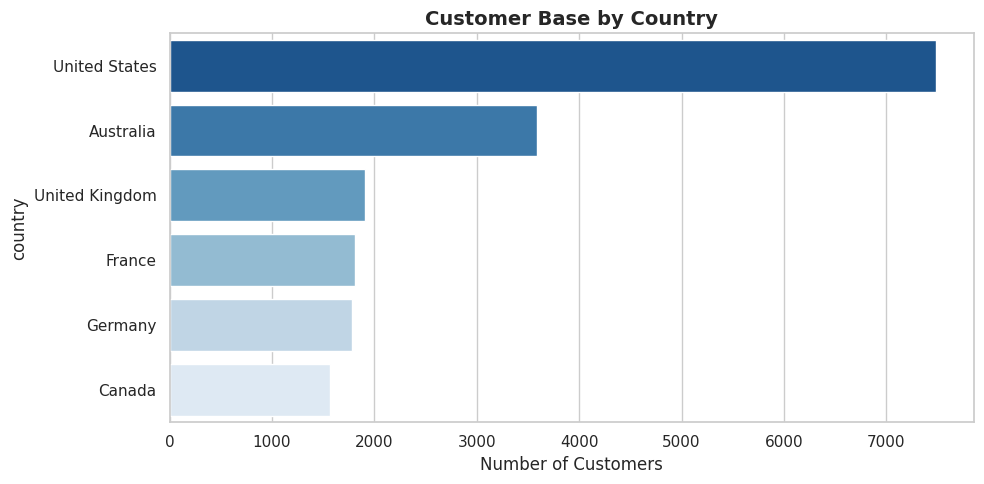

In [12]:
country_counts = dim_customers['country'].value_counts()
print('=== Customers by country ===')
print(country_counts)

plt.figure(figsize=(10, 5))
sns.barplot(x=country_counts.values, y=country_counts.index, palette='Blues_r')
plt.title('Customer Base by Country', fontsize=14)
plt.xlabel('Number of Customers')
plt.tight_layout()
plt.show()


In [13]:
product_line_counts = dim_products['product_line'].value_counts()
print('=== Products by line ===')
print(product_line_counts)
print()
print('=== Maintenance flag ===')
print(dim_products['maintenance'].value_counts())


=== Products by line ===
product_line
Road           97
Mountain       88
Touring        51
Other Sales    35
Name: count, dtype: int64

=== Maintenance flag ===
maintenance
Yes    226
No      62
Name: count, dtype: int64


## 7. Sales Trend by Month

Foundation visualization for forecasting work in notebook 03.


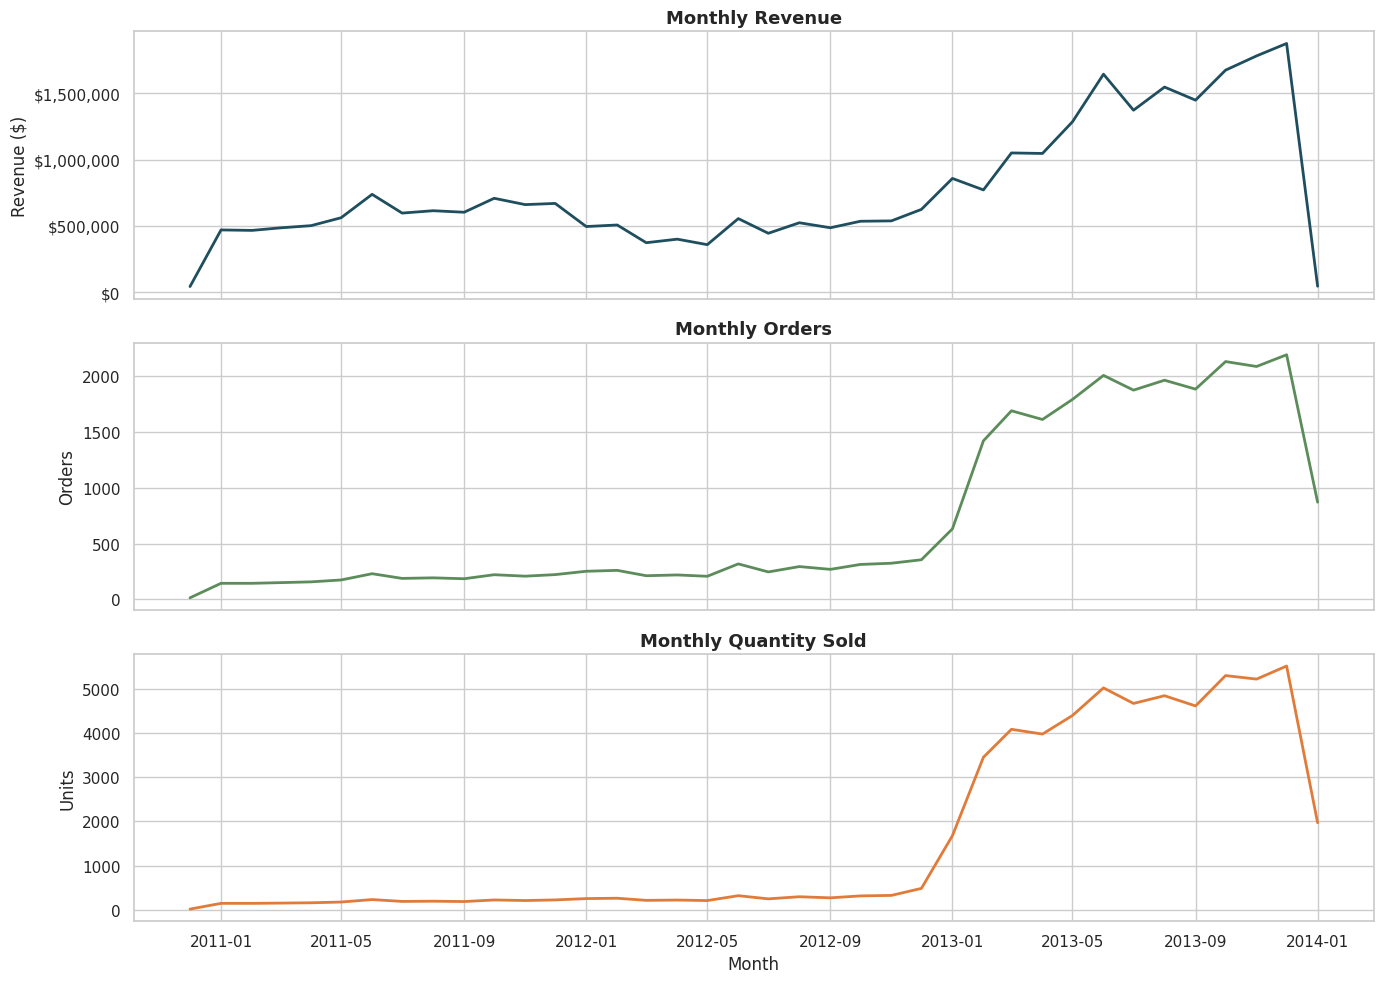

In [14]:
monthly = (
    fact_sales
    .groupby(fact_sales['order_date'].dt.to_period('M'))
    .agg(revenue=('sales_amount', 'sum'),
         orders=('order_number', 'nunique'),
         quantity=('quantity', 'sum'))
    .reset_index()
)
monthly['order_date'] = monthly['order_date'].dt.to_timestamp()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(monthly['order_date'], monthly['revenue'], color='#1F4E5F', linewidth=2)
axes[0].set_title('Monthly Revenue', fontsize=13)
axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'\${x:,.0f}'))

axes[1].plot(monthly['order_date'], monthly['orders'], color='#5B8C5A', linewidth=2)
axes[1].set_title('Monthly Orders', fontsize=13)
axes[1].set_ylabel('Orders')

axes[2].plot(monthly['order_date'], monthly['quantity'], color='#E07B39', linewidth=2)
axes[2].set_title('Monthly Quantity Sold', fontsize=13)
axes[2].set_ylabel('Units')
axes[2].set_xlabel('Month')

plt.tight_layout()
plt.show()


## 8. Revenue Breakdown

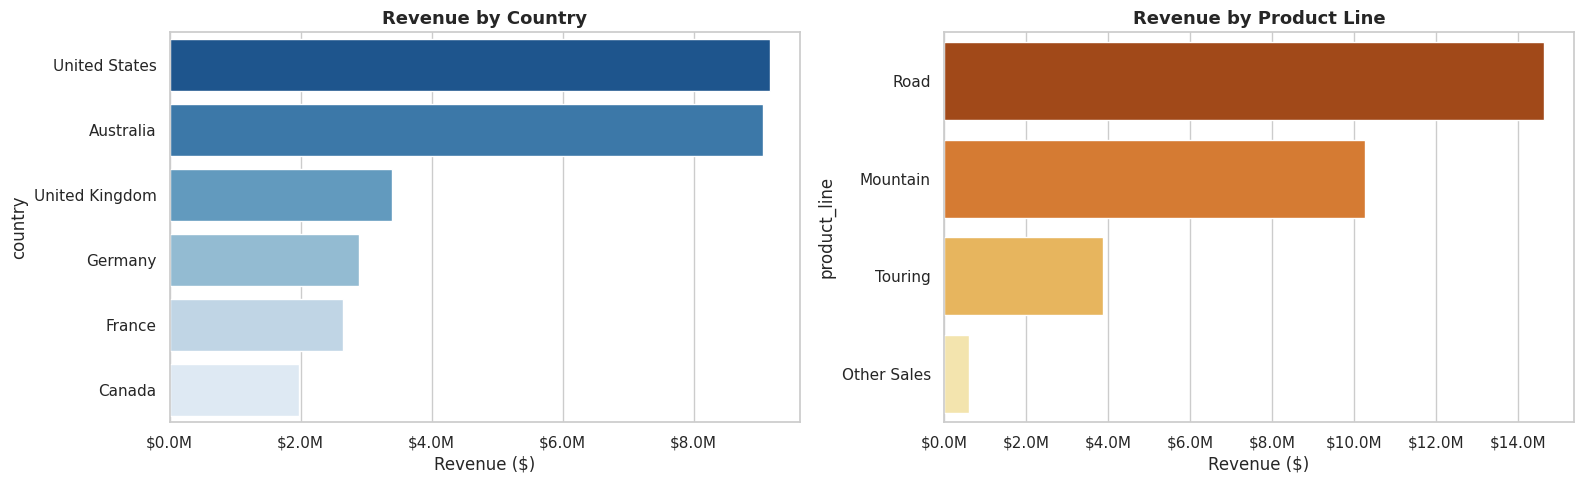

Revenue by country:
country
United States     \$9,162,327
Australia         \$9,060,172
United Kingdom    \$3,391,376
Germany           \$2,894,066
France            \$2,643,751
Canada            \$1,977,738
Name: sales_amount, dtype: str

Revenue by product line:
product_line
Road           \$14,622,850
Mountain       \$10,250,982
Touring         \$3,879,135
Other Sales       \$603,283
Name: sales_amount, dtype: str


In [15]:
# Revenue by country
fact_with_country = fact_sales.merge(
    dim_customers[['customer_key', 'country']], on='customer_key', how='left'
)
revenue_by_country = (
    fact_with_country.groupby('country')['sales_amount']
    .sum().sort_values(ascending=False)
)

# Revenue by product line
fact_with_line = fact_sales.merge(
    dim_products[['product_key', 'product_line', 'category']], on='product_key', how='left'
)
revenue_by_line = (
    fact_with_line.groupby('product_line')['sales_amount']
    .sum().sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=revenue_by_country.values, y=revenue_by_country.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Revenue by Country', fontsize=13)
axes[0].set_xlabel('Revenue ($)')
axes[0].xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'\${x/1e6:.1f}M'))

sns.barplot(x=revenue_by_line.values, y=revenue_by_line.index, palette='YlOrBr_r', ax=axes[1])
axes[1].set_title('Revenue by Product Line', fontsize=13)
axes[1].set_xlabel('Revenue ($)')
axes[1].xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'\${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

print('Revenue by country:')
print(revenue_by_country.apply(lambda x: f'\${x:,.0f}'))
print()
print('Revenue by product line:')
print(revenue_by_line.apply(lambda x: f'\${x:,.0f}'))


## 9. RFM Segments (from Power BI)

These are the segments built in Power BI using quintile-based RFM scoring. We'll validate them with K-Means in the next notebook.


In [16]:
segment_counts = customer_rfm['RFM_Segment'].value_counts()
print('=== Segment sizes ===')
print(segment_counts)
print()
print('=== Segment proportions ===')
print((segment_counts / len(customer_rfm) * 100).round(1).astype(str) + '%')


=== Segment sizes ===
RFM_Segment
Everyday        6923
At Risk         6030
Whales          4796
New Passions     735
Name: count, dtype: int64

=== Segment proportions ===
RFM_Segment
Everyday        37.5%
At Risk         32.6%
Whales          25.9%
New Passions     4.0%
Name: count, dtype: str


In [17]:
# Profile each segment
segment_profile = (
    customer_rfm.groupby('RFM_Segment')
    .agg(customers=('customer_key', 'count'),
         avg_recency=('Recency', 'mean'),
         avg_frequency=('Frequency', 'mean'),
         avg_monetary=('Monetary', 'mean'),
         total_revenue=('Monetary', 'sum'))
    .round(2)
    .sort_values('total_revenue', ascending=False)
)
segment_profile['pct_customers'] = (segment_profile['customers'] / segment_profile['customers'].sum() * 100).round(1)
segment_profile['pct_revenue']  = (segment_profile['total_revenue'] / segment_profile['total_revenue'].sum() * 100).round(1)

print(segment_profile)


              customers  avg_recency  avg_frequency  avg_monetary  total_revenue  pct_customers  pct_revenue
RFM_Segment                                                                                                 
At Risk            6030       284.29           3.22       1652.06      9961912.0           32.6         33.9
Whales             4796        71.17           4.80       2063.57      9896874.0           25.9         33.7
Everyday           6923       201.22           2.48       1337.30      9258125.0           37.5         31.5
New Passions        735        69.31           1.00        325.63       239339.0            4.0          0.8


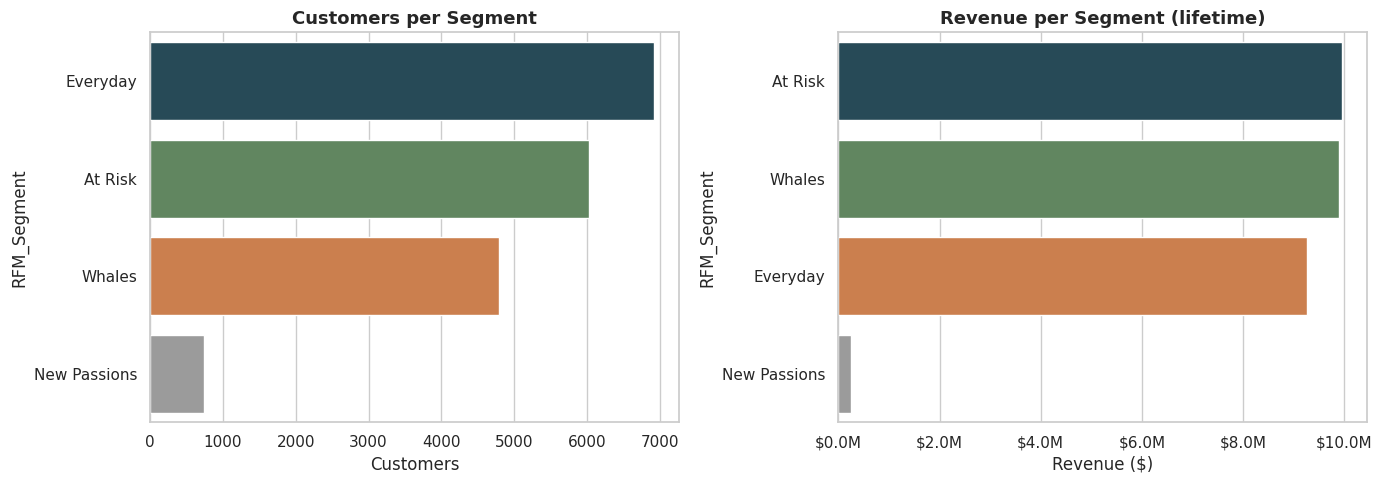

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Customer count by segment
sns.barplot(x=segment_counts.values, y=segment_counts.index,
            palette=['#1F4E5F', '#5B8C5A', '#E07B39', '#9B9B9B'], ax=axes[0])
axes[0].set_title('Customers per Segment', fontsize=13)
axes[0].set_xlabel('Customers')

# Revenue by segment
revenue_by_seg = customer_rfm.groupby('RFM_Segment')['Monetary'].sum().sort_values(ascending=False)
sns.barplot(x=revenue_by_seg.values, y=revenue_by_seg.index,
            palette=['#1F4E5F', '#5B8C5A', '#E07B39', '#9B9B9B'], ax=axes[1])
axes[1].set_title('Revenue per Segment (lifetime)', fontsize=13)
axes[1].set_xlabel('Revenue ($)')
axes[1].xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'\${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()


## 10. Summary

What we know after this notebook:

- **Data is clean and aligned.** 18,484 customers reconcile across `fact_sales`, `dim_customers`, and `customer_rfm`. No orphans.
- **Time coverage:** 37 months, Dec 2010 → Jan 2014. Sufficient for monthly forecasting at the product-line × country level.
- **Geography:** US dominant, Australia second. Europe (UK/DE/FR) and Canada balance the international base.
- **Product mix:** 4 lines — Road dominant by volume, Mountain second. "Other Sales" is accessories.
- **`create_date` is unusable.** All values in 2025-2026. We use first-purchase date instead.
- **4 RFM segments:** Everyday (~38%), At Risk (~33%), Whales (~26%), New Passions (~4%).

**Next steps:**

- **`02_segmentation.ipynb`** — validate the Power BI RFM segments with K-Means clustering. Are the segments statistically coherent?
- **`03_forecasting_baseline.ipynb`** — fit Prophet on monthly sales by product line × country, evaluate with walk-forward backtest.
- **`04_forecasting_lstm.ipynb`** — train PyTorch LSTM as a deep-learning comparison.
- **`05_prescriptive.ipynb`** — combine segments + forecast to produce action lists for marketing, inventory, and customer service.
